In [1]:
## Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
# from statsmodels.formula.api import ols
# import statsmodels.api as sm
# from statsmodels.stats.multicomp import pairwise_tukeyhsd
# import statsmodels.formula.api as smf
import tkinter as tk
from tkinter import filedialog


In [2]:
#abrir dialogue box para seleccionar path de la carpeta
root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename()
xl = pd.ExcelFile(file_path) #datos_completos.xlsx'
df = pd.read_excel(file_path)


In [3]:
df


,Unnamed: 0,index,texto,farber,farbeg,farbeb,rt,participant,condition,perfil_color,color
0,0,0,naranja,NaN,NaN,NaN,1.069,UPC_CG,palabra_negra,negro,negro
1,1,1,azul,NaN,NaN,NaN,0.953,UPC_CG,palabra_negra,negro,negro
2,2,2,verde,NaN,NaN,NaN,0.952,UPC_CG,palabra_negra,negro,negro
3,3,3,verde,NaN,NaN,NaN,0.813,UPC_CG,palabra_negra,negro,negro
4,4,4,azul,NaN,NaN,NaN,0.832,UPC_CG,palabra_negra,negro,negro
...,...,...,...,...,...,...,...,...,...,...,...
1570,1570,100,lila,-1.0,0.04,-1.0,2.755,UPC_Santi,palabra_color,negro,verde
1571,1571,101,lila,1.0,0.10,-1.0,1.435,UPC_Santi,palabra_color,negro,naranja
1572,1572,102,verde,-1.0,-1.00,1.0,0.866,UPC_Santi,palabra_color,negro,azul
1573,1573,103,lila,-1.0,0.04,-1.0,1.402,UPC_Santi,palabra_color,negro,verde


# Plots

### barplot

In [4]:
# sns.barplot(x='condition', y='rt', data=df, palette=['darkorange', 'darkblue', 'lightcoral'], estimator=np.mean)

# plt.gca().spines['right'].set_visible(False)  # aesthetics                                                                              # remove right spines
# plt.gca().spines['top'].set_visible(False)                                                                                  # remove top spines
# plt.gca().get_xaxis().tick_bottom()                                                                                         
# plt.gca().get_yaxis().tick_left()
# plt.gca().tick_params(direction='in') #direction
# plt.xticks([0,1,2], ['negras', 'rectángulo', 'color'])
# plt.xlabel('')
# plt.ylabel('reaction time (s)')
# #plt.ylim(0, 1.5);

### boxplot + trials

In [5]:
# sns.boxplot(x = "condition",  y = "rt",  data = df, 
#             palette=['darkorange', 'darkblue', 'lightcoral'])

# sns.stripplot(x = "condition",  y = "rt",  data = df,
#              palette=['darkorange', 'darkblue', 'lightcoral'])


# plt.gca().spines['right'].set_visible(False)  # aesthetics                                                                              # remove right spines
# plt.gca().spines['top'].set_visible(False)                                                                                  # remove top spines
# plt.gca().get_xaxis().tick_bottom()                                                                                         
# plt.gca().get_yaxis().tick_left()
# plt.gca().tick_params(direction='in') #direction
# plt.xticks([0,1,2], ['negras', 'rectángulo', 'color'])
# plt.xlabel('')
# plt.ylabel('reaction time (s)')
# plt.ylim(0, 2.5);

### confidence interval + subjects 

In [6]:
from matplotlib.patches import Rectangle


def bootstrap_ci(data):
    # Calculamos la media de los datos
    data_mean = np.mean(data)

    # Definimos la cantidad de muestras bootstrap que queremos generar
    n_bootstraps = 1000

    # Generamos muestras bootstrap con reemplazo
    bootstrap_samples = np.random.choice(data, size=(n_bootstraps, len(data)), replace=True)

    # Calculamos la media de cada muestra bootstrap
    bootstrap_means = np.mean(bootstrap_samples, axis=1)

    # Ordenamos las medias bootstrap de menor a mayor
    sorted_means = np.sort(bootstrap_means)

    # Calculamos los percentiles 2.5 y 97.5 de las medias bootstrap
    ci_lower = sorted_means[int(0.025 * n_bootstraps)]
    ci_upper = sorted_means[int(0.975 * n_bootstraps)]

    return ci_lower, ci_upper



In [7]:
df.condition.unique()

array(['palabra_negra', 'rectangulo', 'palabra_color'], dtype=object)

In [8]:
m_pn=df.loc[df['condition']=='palabra_negra', 'rt'].mean()
ci_pn= bootstrap_ci(df.loc[df['condition']=='palabra_negra', 'rt'].values)

m_r=df.loc[df['condition']=='rectangulo', 'rt'].mean()
ci_r= bootstrap_ci(df.loc[df['condition']=='rectangulo', 'rt'].values)

m_pc=df.loc[df['condition']=='palabra_color', 'rt'].mean()
ci_pc= bootstrap_ci(df.loc[df['condition']=='palabra_color', 'rt'].values)


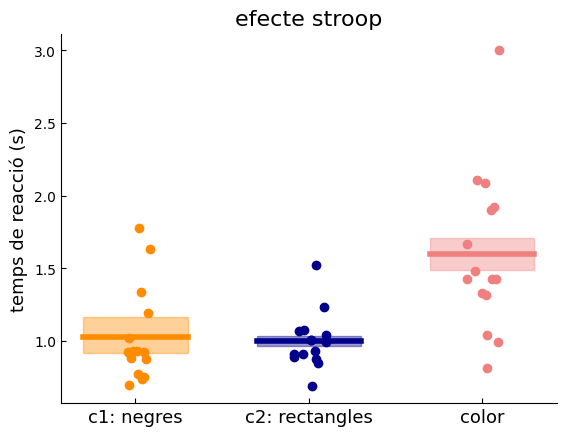

In [9]:
###

idxs_x = [0,1,2]
palette=['darkorange', 'darkblue', 'lightcoral']
cis = [ci_pn, ci_r, ci_pc]
means = [m_pn, m_r, m_pc]

for idx, cond in enumerate(['palabra_negra', 'rectangulo', 'palabra_color']):
    
    ##plot_rectange
    plt.gca().add_patch(Rectangle((idx, cis[idx][0]), 0.6, cis[idx][1]-cis[idx][0], 
                                  alpha=0.4, fill=True, facecolor=palette[idx],
                                  linewidth=1,  edgecolor=palette[idx]))  
    ##plot_mean
    plt.plot([idx, idx+0.6], [means[idx], means[idx]], color=palette[idx], linewidth=4) 
    
    ##
    subj_values = df.loc[df['condition']==cond].groupby('participant', as_index=False)['rt'].mean().rt.values
    for i in range(len(subj_values)):
        jitter=np.random.uniform(-0.1, 0.1)
        plt.plot(idx+0.3+jitter, subj_values[i], color=palette[idx], marker='o', markersize=6 )
    


plt.gca().spines['right'].set_visible(False)  # aesthetics                                                                              # remove right spines
plt.gca().spines['top'].set_visible(False)                                                                                  # remove top spines
plt.gca().get_xaxis().tick_bottom()                                                                                         
plt.gca().get_yaxis().tick_left()
plt.gca().tick_params(direction='in') #direction
plt.xticks([0+0.3,1+0.3,2+0.3], ['c1: negres', 'c2: rectangles', 'color'], fontsize=13)
plt.xlabel('')
plt.ylabel('temps de reacció (s)', fontsize=13)
plt.yticks(fontsize=10)
plt.title('efecte stroop', fontsize=16)
#plt.ylim(0.5, 1.5);
plt.show(block=False)





### historgram trials

C:\Users\david\AppData\Local\Temp\ipykernel_12152\1664656883.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['condition']=='palabra_negra', 'rt'],  color='darkorange', bins=np.linspace(0,3,60),
C:\Users\david\AppData\Local\Temp\ipykernel_12152\1664656883.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad637275

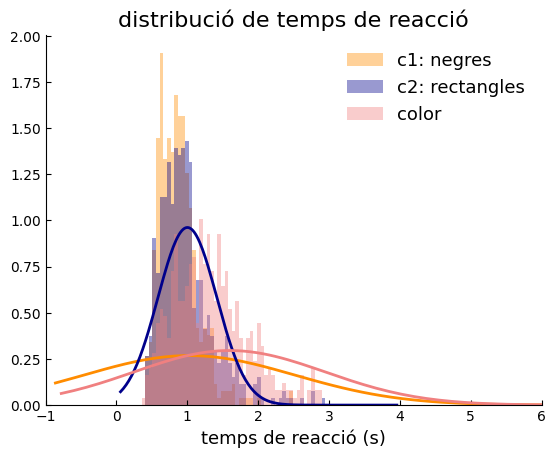

In [10]:

sns.distplot(df.loc[df['condition']=='palabra_negra', 'rt'],  color='darkorange', bins=np.linspace(0,3,60),
             fit=norm, kde=False, fit_kws={"color":'darkorange', 'linewidth':2}, label='c1: negres')

sns.distplot(df.loc[df['condition']=='rectangulo', 'rt'],  color='darkblue', bins=np.linspace(0,3,60),
             fit=norm, kde=False, fit_kws={"color":'darkblue', 'linewidth':2}, label='c2: rectangles' )

sns.distplot(df.loc[df['condition']=='palabra_color', 'rt'],  color='lightcoral', bins=np.linspace(0,3,60),
             fit=norm, kde=False, fit_kws={"color":'lightcoral', 'linewidth':2}, label='color' )

plt.gca().spines['right'].set_visible(False)  # aesthetics                                                                              # remove right spines
plt.gca().spines['top'].set_visible(False)                                                                                  # remove top spines
plt.gca().get_xaxis().tick_bottom()                                                                                         
plt.gca().get_yaxis().tick_left()
plt.gca().tick_params(direction='in') #direction
plt.legend(loc=1, frameon=False, prop={'size': 13})
plt.xlabel('temps de reacció (s)', fontsize=13)
plt.xlim(-1,6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10);
plt.title('distribució de temps de reacció', fontsize=16)
plt.show(block=False)




# Stats

#### Anova + multiple comparisons (simple)
##### The correct Anova should be paired

In [11]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [12]:

df_stats = df.copy()
df_stats['condition']= df_stats['condition'].replace(['palabra_negra', 'rectangulo', 'palabra_color'], ['control 1', 'control 2', 'test'])

mod = smf.ols(formula='rt ~ condition', data=df_stats).fit()
aov_table = sm.stats.anova_lm(mod, typ=2)

print( '                                 ')
print( '                                 Anova Table')
print( '==============================================================================')
print( aov_table)
print( '==============================================================================')
print( '                                 ')
print( '                                 ')
print( '                                 ')



####### Multiple comparisons
tukey = pairwise_tukeyhsd(endog=df_stats.rt.values, groups=df_stats['condition'].values,  alpha=0.05)
print( tukey.summary()    )
print( '                                 ')
print( '                                ')


                                 
                                 Anova Table
                sum_sq      df          F        PR(>F)
condition   118.644103     2.0  42.183815  1.427264e-18
Residual   2210.664555  1572.0        NaN           NaN
                                 
                                 
                                 
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
control 1 control 2  -0.0274 0.9257 -0.1991 0.1443  False
control 1      test    0.568    0.0  0.3963 0.7397   True
control 2      test   0.5954    0.0  0.4237 0.7671   True
---------------------------------------------------------
                                 
                                


#### regression (subjects random intercepts - complex)

In [13]:
resultados = smf.mixedlm(formula='rt ~ condition', data=df_stats, groups=df_stats['participant']).fit()
print(resultados.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    rt        
No. Observations:    1575       Method:                REML      
No. Groups:          15         Scale:                 1.3310    
Min. group size:     105        Log-Likelihood:        -2478.6722
Max. group size:     105        Converged:             Yes       
Mean group size:     105.0                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               1.029    0.089 11.571 0.000  0.854  1.203
condition[T.control 2] -0.027    0.071 -0.385 0.700 -0.167  0.112
condition[T.test]       0.568    0.071  7.977 0.000  0.428  0.708
Group Var               0.080    0.031                           

